In [30]:
import yfinance as yf
import numpy as np
import pandas as pd

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2020-01-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

# 로그 변화율 계산
returns["logchange"] = np.log(returns["Close"] / returns["Close"].shift(1))

# 비율 변화량 계산 (pct_change 사용)
returns["change"] = returns["Close"].pct_change()

# change를 logchange로부터 복구
returns["test"] = np.exp(returns["logchange"]) - 1

# 불필요한 NaN 값 제거
returns = returns.dropna()

# 필요한 열만 선택
returns = returns[["Close", "change", "logchange", "test"]]

print(returns)

[*********************100%***********************]  1 of 1 completed

Price             Close    change  logchange      test
Date                                                  
2020-01-03  3234.850098 -0.007060  -0.007085 -0.007060
2020-01-06  3246.280029  0.003533   0.003527  0.003533
2020-01-07  3237.179932 -0.002803  -0.002807 -0.002803
2020-01-08  3253.050049  0.004902   0.004890  0.004902
2020-01-09  3274.699951  0.006655   0.006633  0.006655
...                 ...       ...        ...       ...
2025-05-02  5686.669922  0.014727   0.014619  0.014727
2025-05-05  5650.379883 -0.006382  -0.006402 -0.006382
2025-05-06  5606.910156 -0.007693  -0.007723 -0.007693
2025-05-07  5631.279785  0.004346   0.004337  0.004346
2025-05-08  5663.939941  0.005800   0.005783  0.005800

[1344 rows x 4 columns]


In [29]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

plt.tight_layout()

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2010-01-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

# returns["change"] = np.log(returns["Close"]).diff()
# returns["change"] = returns["Close"].pct_change()
returns["change"] = np.log(returns["Close"] / returns["Close"].shift(1))
returns = returns.dropna()
returns = returns[["Close", "change"]]
returns[returns["change"] < 0]


/tmp/ipykernel_63498/2278358887.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
[*********************100%***********************]  1 of 1 completed


Price,Close,change
Date,,
2010-01-12,1136.219971,-0.009425
2010-01-15,1136.030029,-0.010882
2010-01-20,1138.040039,-0.010654
2010-01-21,1116.479980,-0.019127
2010-01-22,1091.760010,-0.022390
...,...,...
2025-04-15,5396.629883,-0.001729
2025-04-16,5275.700195,-0.022663
2025-04-21,5158.200195,-0.023850


<Figure size 720x480 with 0 Axes>

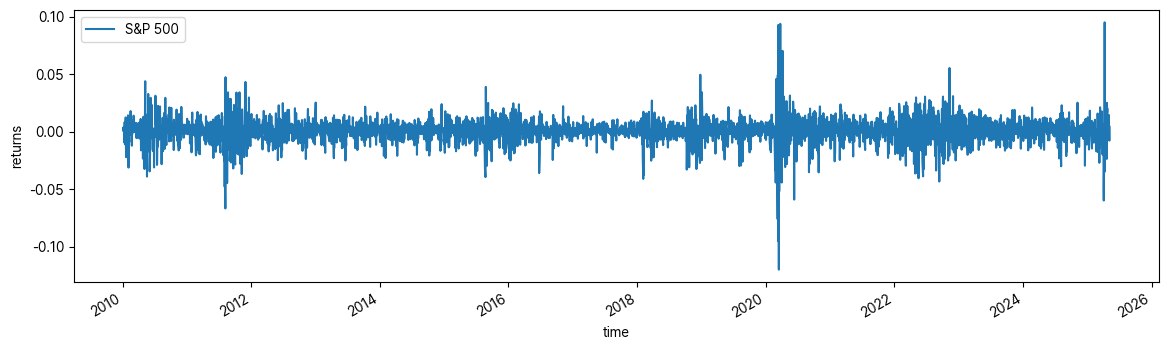

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
returns.plot(y="change", label="S&P 500", ax=ax)
ax.set(xlabel="time", ylabel="returns")
ax.legend();

In [4]:
def make_stochastic_volatility_model(data):
    with pm.Model(coords={"time": data.index.values}) as model:
        step_size = pm.Exponential("step_size", 10)
        volatility = pm.GaussianRandomWalk("volatility", sigma=step_size, dims="time")
        nu = pm.Exponential("nu", 0.1)
        returns = pm.StudentT(
            "returns", nu=nu, lam=np.exp(-2 * volatility), observed=data["change"], dims="time"
        )
    return model


stochastic_vol_model = make_stochastic_volatility_model(returns)

/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


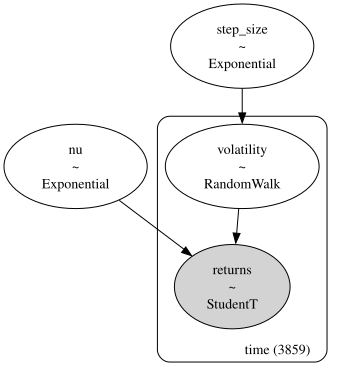

In [5]:
pm.model_to_graphviz(stochastic_vol_model)

In [6]:
rng = np.random.RandomState(1234)
az.style.use("arviz-darkgrid")

In [7]:
with stochastic_vol_model:
    idata = pm.sample_prior_predictive(500, random_seed=rng)

prior_predictive = idata.prior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [nu, returns, step_size, volatility]


In [8]:
idata

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

In [9]:
prior_predictive

<xarray.Dataset>
Dimensions:       (time: 3859, pooled_chain: 500)
Coordinates:
  * time          (time) datetime64[ns] 2010-01-05 2010-01-06 ... 2025-05-07
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
  * draw          (pooled_chain) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
Data variables:
    returns       (time, pooled_chain) float64 7.807e+44 ... -2.489e-51
Attributes:
    created_at:                 2025-05-08T14:58:57.715926
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0

In [10]:
prior_predictive["returns"].shape

(3859, 500)

/tmp/ipykernel_63498/3549709644.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


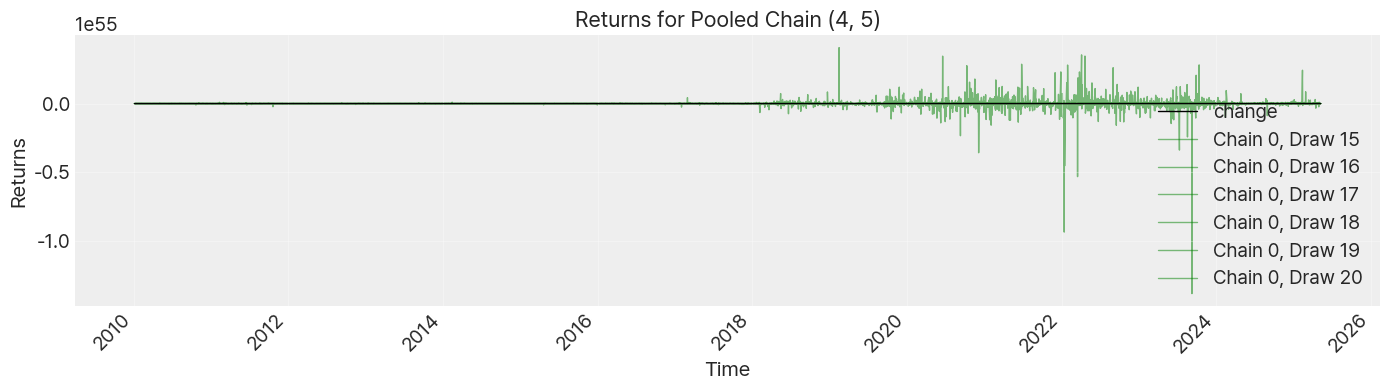

In [11]:

subset = prior_predictive["returns"].isel(pooled_chain=slice(15, 21, None))

# 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 4))
returns["change"].plot(ax=ax, lw=1, color="black")
for i in range(subset.pooled_chain.size):
    chain, draw = subset.pooled_chain.values[i]
    label = f"Chain {chain}, Draw {draw}"
    plt.plot(subset.time, subset[:, i], label=label, color="g",
    alpha=0.5,
    lw=1,
    zorder=-10,)

plt.title("Returns for Pooled Chain (4, 5)")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
with stochastic_vol_model:
    idata.extend(pm.sample(3000, random_seed=rng, target_accept=0.95, idata_kwargs={"log_likelihood": True}))

posterior = idata.posterior.stack(pooled_chain=("chain", "draw"))
# posterior["volatility"] = np.exp(posterior["volatility"])

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [step_size, volatility, nu]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 546 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [13]:
posterior["volatility"]

<xarray.DataArray 'volatility' (time: 3859, pooled_chain: 12000)>
array([[-4.40851762, -4.85159699, -4.53424379, ..., -4.8155634 ,
        -5.37809073, -4.88828342],
       [-4.23166523, -4.74114361, -4.44393696, ..., -4.72349337,
        -5.30981081, -4.88488229],
       [-4.25602249, -4.7752514 , -4.29196994, ..., -4.65466032,
        -5.25290983, -4.95084424],
       ...,
       [-4.59226664, -4.40429224, -4.28350596, ..., -4.17245492,
        -3.82721404, -4.50678333],
       [-4.43043737, -4.17339543, -4.35325133, ..., -4.22225746,
        -3.93833794, -4.60509264],
       [-4.54226769, -4.16755479, -4.36723545, ..., -4.40395676,
        -3.9186947 , -4.45879686]])
Coordinates:
  * time          (time) datetime64[ns] 2010-01-05 2010-01-06 ... 2025-05-07
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw          (pooled_chain) int64 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999

In [14]:
posterior

<xarray.Dataset>
Dimensions:       (time: 3859, pooled_chain: 12000)
Coordinates:
  * time          (time) datetime64[ns] 2010-01-05 2010-01-06 ... 2025-05-07
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw          (pooled_chain) int64 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999
Data variables:
    volatility    (time, pooled_chain) float64 -4.409 -4.852 ... -3.919 -4.459
    step_size     (pooled_chain) float64 0.1107 0.1099 0.1128 ... 0.1005 0.09769
    nu            (pooled_chain) float64 21.51 25.35 32.13 ... 16.25 15.64 10.74
Attributes:
    created_at:                 2025-05-08T15:08:07.260192
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              545.9265224933624
    tuning_steps:               1000

In [15]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [16]:
summary = az.summary(idata)
summary[summary["r_hat"] > 1.0].sort_values("r_hat", ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
step_size,0.1,0.008,0.085,0.114,0.001,0.0,139.0,354.0,1.03


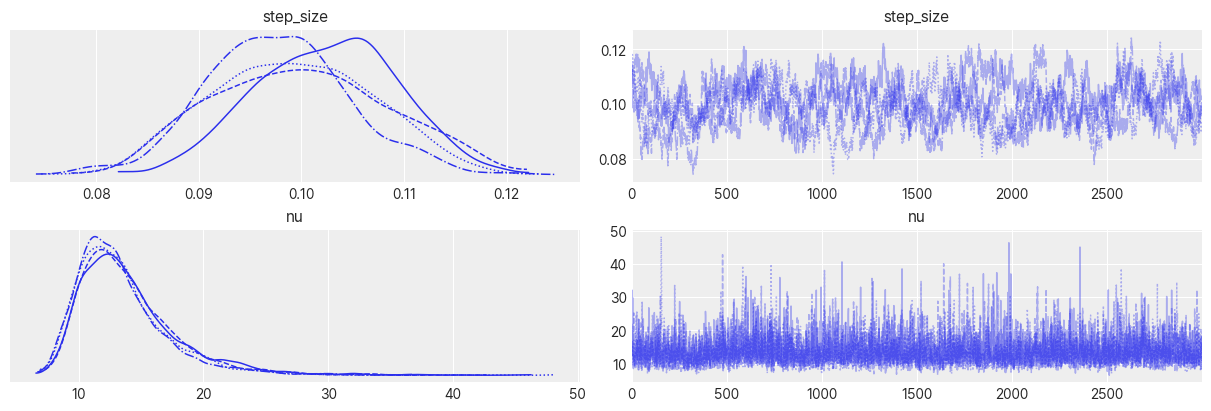

In [17]:
az.plot_trace(idata, var_names=["step_size", "nu"]);

In [18]:
az.loo(idata)

Computed from 12000 posterior samples and 3859 observations log-likelihood matrix.

         Estimate       SE
elpd_loo 12930.12    58.92
p_loo      226.20        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     3832   99.3%
 (0.5, 0.7]   (ok)         27    0.7%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [19]:
with stochastic_vol_model:
    posterior_predictive = pm.sample_posterior_predictive(idata, random_seed=rng)

# posterior_predictive = posterior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [returns]


In [20]:
posterior_predictive

Inference data with groups:
	> posterior_predictive
	> observed_data

In [21]:
posterior_predictive.posterior_predictive["returns"].shape

(4, 3000, 3859)

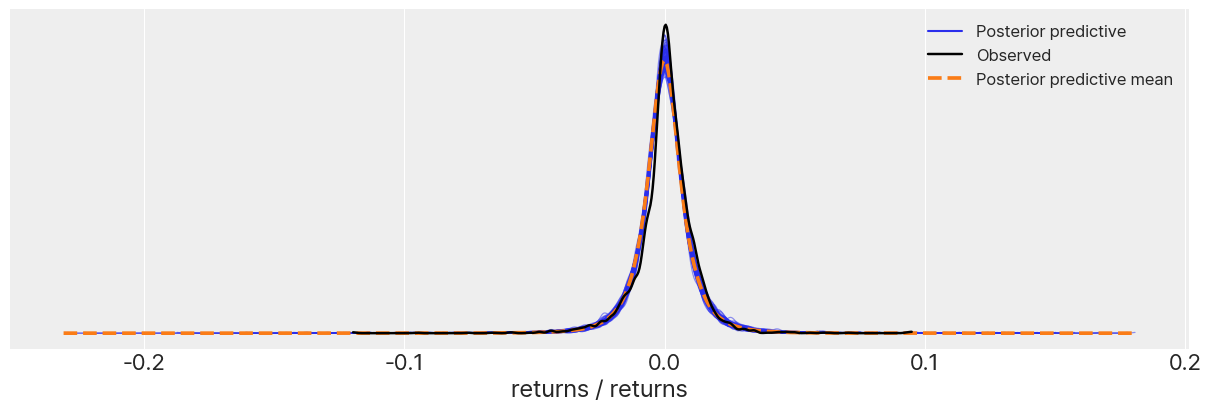

In [22]:
az.plot_ppc(posterior_predictive, num_pp_samples=100, figsize=(12, 4), kind="kde", alpha=0.5);

<Axes: title={'center': 'returns / returns'}>

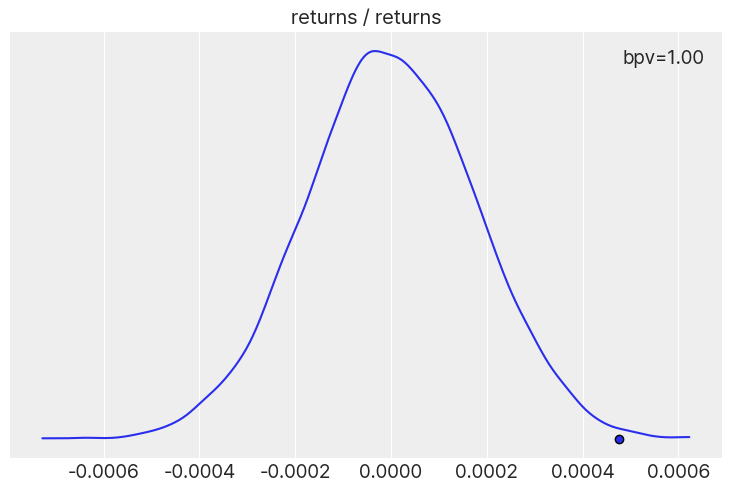

In [23]:
az.plot_bpv(posterior_predictive, kind="t_stat", t_stat="mean")

In [24]:
posterior

<xarray.Dataset>
Dimensions:       (time: 3859, pooled_chain: 12000)
Coordinates:
  * time          (time) datetime64[ns] 2010-01-05 2010-01-06 ... 2025-05-07
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw          (pooled_chain) int64 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999
Data variables:
    volatility    (time, pooled_chain) float64 -4.409 -4.852 ... -3.919 -4.459
    step_size     (pooled_chain) float64 0.1107 0.1099 0.1128 ... 0.1005 0.09769
    nu            (pooled_chain) float64 21.51 25.35 32.13 ... 16.25 15.64 10.74
Attributes:
    created_at:                 2025-05-08T15:08:07.260192
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              545.9265224933624
    tuning_steps:               1000

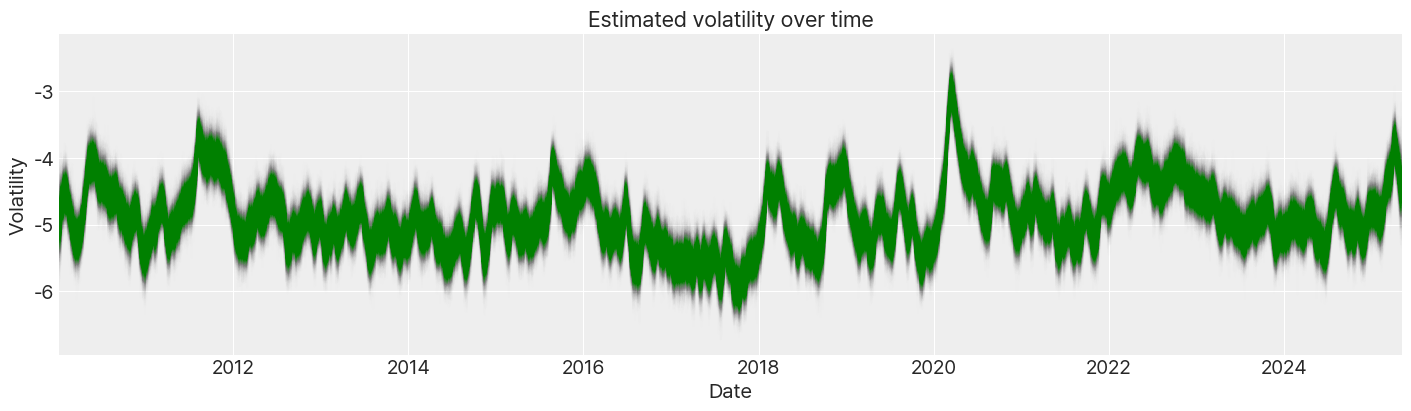

In [25]:
fig, ax = plt.subplots(figsize=(14, 4))

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)

plt.plot(x_vals, y_vals, "g", alpha=0.002)
ax.set_xlim(x_vals.min(), x_vals.max())
# ax.set_ylim(bottom=0)
ax.set(title="Estimated volatility over time", xlabel="Date", ylabel="Volatility");

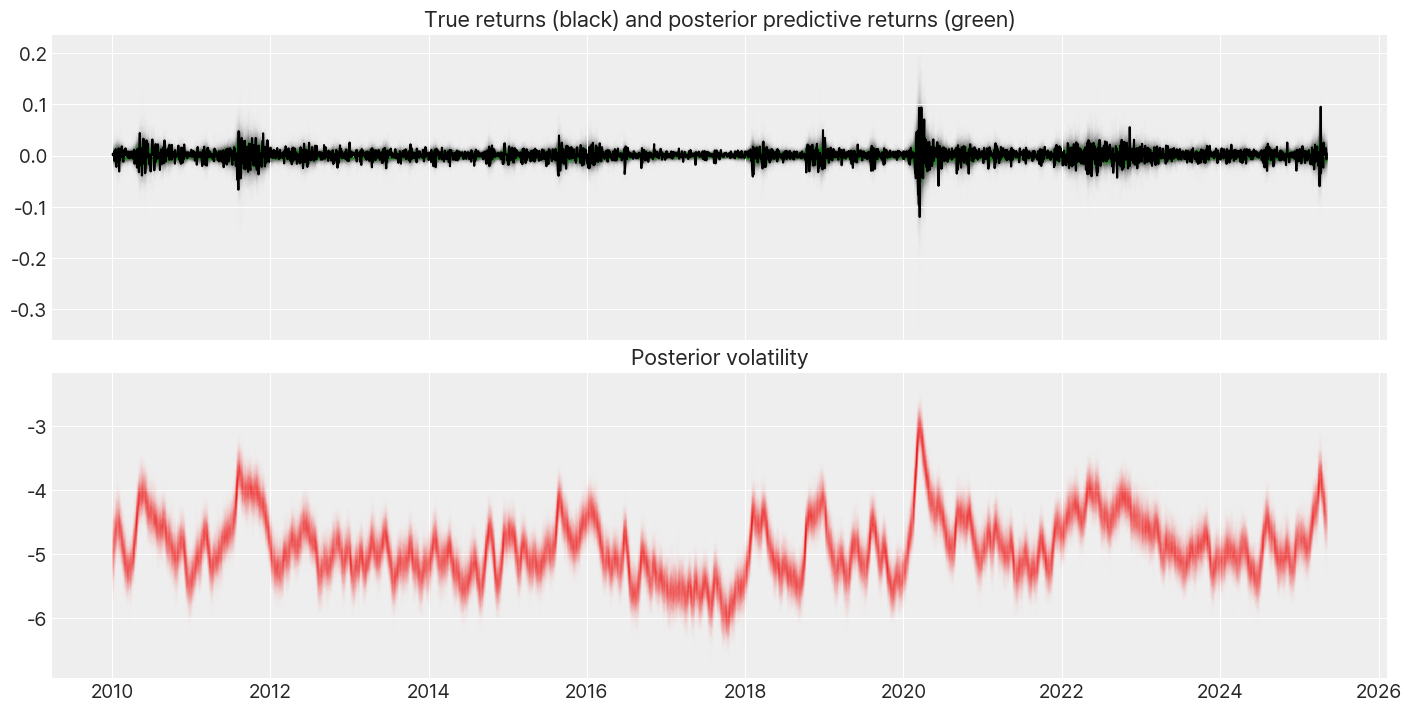

In [26]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["change"].plot(ax=axes[0], color="black")

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 50))
x_vals = y_vals.time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.002)

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 50))
# y_vals = np.exp(y_vals) - 1
x_vals = y_vals.time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.002,
    zorder=-10)
axes[0].set_title("True returns (black) and posterior predictive returns (green)")
axes[1].set_title("Posterior volatility");
# plt.xlim(x_vals[-100], x_vals.max())

In [27]:
with stochastic_vol_model:
    posterior_predictive = pm.sample_posterior_predictive(idata, random_seed=rng)

Sampling: [returns]
